In [11]:
import random
import numpy as np
from math import log, sqrt
import bamnostic
import seqlogo as sl
import pandas as pd

# Functions

## Small helpers

In [ ]:
BASE_INDEX = {"A": 0, "C": 1, "G": 2, "T": 3}

def add_kmer_to_pfm(pfm: np.ndarray, kmer: str, sign: int) -> None:
    """
    in-place add (sign=+1) or remove (sign=-1) a k-mer from PFM.
    """
    for j, ch in enumerate(kmer):
        pfm[BASE_INDEX[ch], j] += sign

def frobenius_norm(mat: np.ndarray) -> float:
    return sqrt(float(np.sum(mat * mat)))

    #ie. square every cell, sum all squared entries, float it

def is_valid_kmer(seq): # boolean helper 
    return all(ch in BASE_INDEX for ch in seq)

## Background model builder

In [15]:
### 0th-order bg model ###
def build_markov_0th_order(reads: list, pseudocount: float) -> dict:
    '''
    input: list of reads and background pseudocount
    returns a dict like {"A":pA,"C":pC,"G":pG,"T":pT}
    '''

    if pseudocount <= 0:
        raise ValueError("pseudocount must be > 0")

    a = c = g = t = 0

    for read in reads:
        if not read:
            continue
        r = read.upper()

        a += r.count("A")
        c += r.count("C")
        g += r.count("G")
        t += r.count("T")

    total = (a + c + g + t) + pseudocount * 4

    return {
        "A": (a + pseudocount) / total,
        "C": (c + pseudocount) / total,
        "G": (g + pseudocount) / total,
        "T": (t + pseudocount) / total,
    }


## PFM/PWM builders

In [ ]:
### matrix stuff ###

def build_pfm(sequences, length) -> np.ndarray:
    # like build_pfm from motif_ops but doesn't silently turn invalid characters into As
    pfm = np.zeros((4, length), dtype=np.int32)

    # one slot for every possible byte value, all initially -1
    base_to_index = np.full(256, -1, dtype=np.int16)
    base_to_index[ord('A')] = 0
    base_to_index[ord('C')] = 1
    base_to_index[ord('G')] = 2
    base_to_index[ord('T')] = 3

    cols = np.arange(length)

    for seq in sequences:
        seq_array = np.frombuffer(seq[:length].encode(), dtype=np.uint8)
        indices = base_to_index[seq_array]

        # only count valid A/C/G/T
        mask = indices >= 0
        np.add.at(pfm, (indices[mask], cols[mask]), 1)

    return pfm

def build_pwm(pfm, bg, pseudocount) -> np.ndarray:
    """
    PWM[b,j] = log2( P_motif(b|j) / P_bg(b) )
    pfm: (4, k) counts
    bg: dict like {"A":pA,"C":pC,"G":pG,"T":pT}
    """

    # like build_pwm from motif_ops but the background probs arent hardcoded
    # this format also only works for 0th order background models

    # bg (4, 1), it's a column vector in A,C,G,T order
    bg_vec = np.array([bg[b] for b in ("A", "C", "G", "T")], dtype=float).reshape(4, 1)

    # column sums (1, k)
    sums = pfm.sum(axis=0, keepdims=True) + 4 * pseudocount

    # motif probabilities (4, k)
    p_motif = (pfm.astype(float) + pseudocount) / sums

    # log-odds vs background
    pwm = np.log2(p_motif) - np.log2(bg_vec)

    return pwm


## Scoring

In [ ]:
TRANS_TAB = str.maketrans('ACGT', '0123')
def score_kmer(seq: str, pwm: np.ndarray) -> float:
    # this is as it is in motif_ops
    """
    Score a k-mer using a Position Weight Matrix (PWM).

    The k-mer length is expected to be the same as the PWM length.

    Args:
        seq (str): k-mer to score.
        pwm (np.ndarray): PWM for scoring.

    Returns:
        float: PWM score for the k-mer.

    Raises:
        ValueError: If the k-mer and PWM are different lengths.
    """
    if len(seq) != len(pwm[0]):
        raise ValueError('K-mer and PWM are different lengths!')

    indices = np.fromiter((int(nt) for nt in seq.translate(TRANS_TAB)), dtype = int)
    return np.sum(pwm[indices, np.arange(len(indices))])

def pfm_ic(pfm: np.ndarray, p) -> float:
    #like pfm_ic in motif_ops, but motif pseudocount is parameterized
    sums = np.sum(pfm, axis=0) + 4 * p
    fij = (pfm + p) / sums
    ic = np.sum(2 + np.sum(fij * np.log2(fij), axis=0, where=fij > 0))
    return ic

## Main algorithm logic

In [17]:
### initiation function ###

def init_sites_and_matrices(reads, k, bg, seed, max_tries, pseudocount) -> \
    (list[int], list[str], np.ndarray, np.ndarray):
    """
    initiation:
    - choose random start positions for each read
    - build initial PFM/PWM from chosen k-mers

    input: reads, k, bg, seed, max tries (for choosing initial motif windows), motif pseudocount
    output: starts, candidates, pfm (integers), pwm (floats)
    """
    rng = random.Random(seed)

    starts = []
    candidates = []

    for read in reads:
        read=read.upper()
        L = len(read)
        if L < k:
            raise ValueError("all reads must have length >= k")
        
        for _ in range(max_tries):
            start = rng.randrange(0, L - k + 1)
            kmer = read[start:start + k]
            if is_valid_kmer(kmer):
                starts.append(start)
                candidates.append(kmer)
                break 
        else:
            raise ValueError("could not sample a valid initial k-mer from read")
        

    pfm = build_pfm(candidates, k)
    pwm = build_pwm(pfm, bg, pseudocount=pseudocount)

    return starts, candidates, pfm, pwm

In [18]:
############# ONE GIBBS UPDATE ##############

LN2 = log(2.0)

def gibbs_update(
    reads: list[str], starts: list[int], pfm: np.ndarray,
    i: int, k: int, bg: dict, 
    motif_pseudocount: float, 
    rng: random.Random, 
    max_tries: int = 50 ) -> int:
    '''
    performs one gibbs move updating read i.
    
    effects are:
        changes start[i].
        changes pfm.
    
    returns the newly sampled start index for the read. 
    '''

    read = reads[i].upper() # identify the read
    L = len(read)

    if L < k:
        raise ValueError("Read length < k")

    # identify current start position
    old_start = starts[i]

    # identify current candidate motif
    old_kmer = read[old_start:old_start + k]

    # uncount kmer in pfm
    add_kmer_to_pfm(pfm, old_kmer, sign=-1)

    # leave-one-out PWM 
    loo_pwm = build_pwm(pfm, bg, pseudocount=motif_pseudocount)

    # number of starts to score
    n_starts = L - k + 1

    # initialize scores array and validity mask
    scores = np.zeros(n_starts, dtype=float) 
    valid = np.zeros(n_starts, dtype=bool) 

    # score each start to create a probability distribution
    for start in range(n_starts):

        kmer = read[start:start + k]

        if is_valid_kmer(kmer):
            valid[start] = True
            scores[start] = score_kmer(kmer, loo_pwm)
            # scores = log2(P(kmer|motif)/P(kmer|bg))
        else:
            continue

    valid_windows = np.flatnonzero(valid)
    if valid_windows.size == 0:
        # no valid windows; restore old k-mer if we removed it and keep start unchanged
        # defensive programming. init already found a valid window
        if is_valid_kmer(old_kmer):
            add_kmer_to_pfm(pfm, old_kmer, sign=+1) # put everything back
        return old_start

    #convert to weights
    m = float(np.max(scores[valid_windows])) # max score found
    w = np.zeros_like(scores) # initialize scores vector; the invalid windows will keep weight 0

    w[valid] = np.exp((scores[valid] - m) * LN2) # 2^x=(e^(ln2))^x=e^(xln2)
    # with x = score - max score, we keep weights between 0 and 1
    # the max scoring window has weight 2^x = 2^0 = 1, for everything else x is negative so 2^x is between 0 and 1
    # ie. cannot overflow and also makes debugging easier if it comes up

    # random choice
    # choices() wants lists
    population = valid_windows.tolist() 
    w_list = w[valid].tolist()

    # choose new start probabilisitically
    new_start = rng.choices(population, weights=w_list, k=1)[0]

    # count new motif candidate in pfm
    new_kmer = read[new_start:new_start + k]
    add_kmer_to_pfm(pfm, new_kmer, sign=+1)
    starts[i] = new_start

    # print(f"""
    # read n. {i}:
    # start position {old_start} -> {new_start}
    # """)

    return new_start

In [19]:
##### ALGORITHM WRAPPER #####

def GibbsMotifSampler(
    k: int, 
    seqs: list[str], 
    bg_sample: list[str] | None = None, # if it's None use seqs,
    seed: int = 123,
    bg_pseudocount: float = 1.0, 
    motif_pseudocount: float = 0.25,
    max_tries_init: int = 50, 
    burn_in_sweeps: int = 1,
    check_every_sweeps: int = 10,
    rel_thresh: float = 0.001,
    max_sweeps: int = 100
    ) -> np.ndarray:

    if k <= 0:
        raise ValueError("k must be > 0")
    if not seqs:
        raise ValueError("seqs must be non-empty")

    # 0th order iid background
    if bg_sample is None:
        bg_sample = seqs
    if not bg_sample:
        raise ValueError("bg_sample was provided but is empty")
 
    bg = build_markov_0th_order(bg_sample, bg_pseudocount)

    ###### INITIATION ##########
    rng = random.Random(seed)
    starts, candidates, pfm, pwm = \
        init_sites_and_matrices(
            seqs, k, bg, seed=seed, max_tries=max_tries_init, pseudocount=motif_pseudocount
            )
    
    print("burning in...")
    prev_pwm = None
    n = len(seqs)
    ######### ITERATION ###########
    for sweep in range(1, max_sweeps + 1):
        # one sweep = n single updates
        
        for _ in range(n):
            i = rng.randrange(0, len(seqs))
            gibbs_update(seqs, starts, pfm, i, k, bg, motif_pseudocount, rng)

        if sweep <= burn_in_sweeps: # are we still in burn-in
            continue
        if sweep == (burn_in_sweeps+1):
            print("..done burning in...")
        if (sweep - burn_in_sweeps) % check_every_sweeps != 0: # is it not checking time
            continue


        #### CHECK CONVERGENCE #####
        pwm_now = build_pwm(pfm, bg, pseudocount=motif_pseudocount)

        if prev_pwm is None:
            prev_pwm = pwm_now
            continue

        diff = pwm_now - prev_pwm

        num = frobenius_norm(diff)
        den = frobenius_norm(prev_pwm)
        rel = num / den if den > 0 else float("inf")

        prev_pwm = pwm_now
        ic = pfm_ic(pfm,motif_pseudocount)
        print(f"""
        {sweep} sweeps complete,
        IC = {ic:3f},
        relative Frobenius diff = {rel:3f}
        """)

        if rel < rel_thresh:
            break

    return pfm

# Implementation

## Note on input data

This workflow requires at least a line-separated file of sequences which will serve as windows in which we look for the motif.
If a separate line-separated file of sequences is provided to build the 0th order background Markov model, it will be used, otherwise the windows themselves will be used. In the example below, flanking regions which do not overlap with the window of candidates are used as a basis the background model.

The example uses outputs from supplementary scripts; see README.md.

burning in...
..done burning in...

        25 sweeps complete,
        IC = 11.713292,
        relative Frobenius diff = 0.339292
        

        35 sweeps complete,
        IC = 11.726025,
        relative Frobenius diff = 0.251060
        

        45 sweeps complete,
        IC = 11.729369,
        relative Frobenius diff = 0.320421
        

        55 sweeps complete,
        IC = 11.640649,
        relative Frobenius diff = 0.368843
        

        65 sweeps complete,
        IC = 11.649322,
        relative Frobenius diff = 0.319979
        

        75 sweeps complete,
        IC = 11.645946,
        relative Frobenius diff = 0.276481
        

        85 sweeps complete,
        IC = 11.690098,
        relative Frobenius diff = 0.201219
        

        95 sweeps complete,
        IC = 11.638782,
        relative Frobenius diff = 0.355254
        

        105 sweeps complete,
        IC = 11.696446,
        relative Frobenius diff = 0.302512
        

        115 sweeps

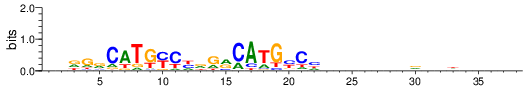

In [ ]:
seed=12345

# get motif windows
with open("window_seqs.txt") as f:
    seqs = [ln.strip().upper() for ln in f if ln.strip()]

# get background-training sequences
with open("flank_seqs.txt") as f: 
    bg_sample = [ln.strip().upper() for ln in f if ln.strip()]

# wrapper
pfm = GibbsMotifSampler(
    k = 38,
    seqs=seqs, 
    bg_sample = bg_sample,
    seed = seed,
    bg_pseudocount = 1.0, 
    motif_pseudocount = 0.25,
    max_tries_init = 5, 
    burn_in_sweeps = 5,
    check_every_sweeps = 10,
    rel_thresh = 0.05,
    max_sweeps = 500
    )

# convert to Pfm object for seqlogo
sl.Pfm(pfm)

# seqlogo.seqlogo 
sl.seqlogo(sl.CompletePm(pfm = pfm.T))